<a href="https://colab.research.google.com/github/Ishan-debugg/Fine-Tuning-LoRA/blob/main/notebooks/Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install all dependencies
# Run this once, then restart runtime

!pip install datasets huggingface_hub jsonschema pandas matplotlib seaborn tqdm
!pip install transformers  # needed for tokenizer length checks later

# Verify installations
import datasets
import jsonschema
import pandas as pd
print(f"datasets version: {datasets.__version__}")
print("All dependencies installed successfully.")

datasets version: 4.0.0
All dependencies installed successfully.


In [2]:
# Cell 2: All imports upfront — understand what each one does
import json
import re
import os
import random
import hashlib
from pathlib import Path
from typing import Optional
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datasets import load_dataset, Dataset, DatasetDict
import jsonschema
from transformers import AutoTokenizer

# ── Configuration ──────────────────────────────────────────────────────────────
# Change these if you want to experiment
CONFIG = {
    "seed": 42,
    "target_train_size": 2500,      # Examples for training
    "min_examples": 2000,           # Minimum acceptable after filtering
    "max_input_tokens": 200,        # Filter out very long inputs
    "min_input_tokens": 10,         # Filter out near-empty inputs
    "train_ratio": 0.80,
    "val_ratio": 0.10,
    "test_ratio": 0.10,             # HOLDOUT — never touch during training
    "output_dir": "./curated_data", # Where to save everything
}

random.seed(CONFIG["seed"])
Path(CONFIG["output_dir"]).mkdir(exist_ok=True)

print("Config loaded:", CONFIG)

Config loaded: {'seed': 42, 'target_train_size': 2500, 'min_examples': 2000, 'max_input_tokens': 200, 'min_input_tokens': 10, 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1, 'output_dir': './curated_data'}


In [5]:
import huggingface_hub
huggingface_hub.login()

In [6]:
# Cell 3: Load the dataset and inspect it
# This will download ~50MB — takes 1-2 mins on Colab

print("Loading Salesforce/xlam-function-calling-60k...")
raw_dataset = load_dataset("Salesforce/xlam-function-calling-60k", split="train")

print(f"\n── Dataset Overview ──")
print(f"Total examples: {len(raw_dataset):,}")
print(f"Columns: {raw_dataset.column_names}")
print(f"Features: {raw_dataset.features}")

Loading Salesforce/xlam-function-calling-60k...


xlam_function_calling_60k.json: reconstructing file:   0%|          |  0.00B / 96.1MB            

xlam_function_calling_60k.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]


── Dataset Overview ──
Total examples: 60,000
Columns: ['id', 'query', 'answers', 'tools']
Features: {'id': Value('int64'), 'query': Value('string'), 'answers': Value('string'), 'tools': Value('string')}


In [7]:
# Cell 4: Look at actual examples — don't skip this
# READ these carefully. This is your data.

print("── First example (raw) ──\n")
example = raw_dataset[0]
for key, value in example.items():
    print(f"[{key}]:")
    print(value)
    print()

print("── Second example ──\n")
example2 = raw_dataset[1]
for key, value in example2.items():
    print(f"[{key}]:")
    print(value)
    print()

── First example (raw) ──

[id]:
0

[query]:
Where can I find live giveaways for beta access and games?

[answers]:
[{"name": "live_giveaways_by_type", "arguments": {"type": "beta"}}, {"name": "live_giveaways_by_type", "arguments": {"type": "game"}}]

[tools]:
[{"name": "live_giveaways_by_type", "description": "Retrieve live giveaways from the GamerPower API based on the specified type.", "parameters": {"type": {"description": "The type of giveaways to retrieve (e.g., game, loot, beta).", "type": "str", "default": "game"}}}]

── Second example ──

[id]:
1

[query]:
I need to understand the details of the Ethereum blockchain for my cryptocurrency project. Can you fetch the details for 'ethereum'?

[answers]:
[{"name": "web_chain_details", "arguments": {"chain_slug": "ethereum"}}]

[tools]:
[{"name": "peers", "description": "Retrieves a list of company peers given a stock symbol.", "parameters": {"symbol": {"description": "The stock symbol for the company.", "type": "str", "default": ""}

In [8]:
# Cell 5: Understand the structure more deeply
# xlam has: 'id', 'query' (input), 'answers' (JSON output), 'tools' (available functions)

print("── Checking data types ──")
sample = raw_dataset[0]

print(f"Type of 'query': {type(sample.get('query', sample.get('input', '')))} ")
print(f"Type of 'answers': {type(sample.get('answers', sample.get('output', '')))}")

# The 'answers' field is usually a stringified JSON list
# Let's see what it looks like parsed
answers_raw = sample.get('answers', sample.get('output', ''))
print(f"\nRaw answers string:\n{answers_raw}")

try:
    answers_parsed = json.loads(answers_raw)
    print(f"\nParsed answers type: {type(answers_parsed)}")
    print(f"Parsed answers content: {json.dumps(answers_parsed, indent=2)}")
except json.JSONDecodeError as e:
    print(f"\n⚠️  This example has INVALID JSON in answers: {e}")

── Checking data types ──
Type of 'query': <class 'str'> 
Type of 'answers': <class 'str'>

Raw answers string:
[{"name": "live_giveaways_by_type", "arguments": {"type": "beta"}}, {"name": "live_giveaways_by_type", "arguments": {"type": "game"}}]

Parsed answers type: <class 'list'>
Parsed answers content: [
  {
    "name": "live_giveaways_by_type",
    "arguments": {
      "type": "beta"
    }
  },
  {
    "name": "live_giveaways_by_type",
    "arguments": {
      "type": "game"
    }
  }
]


In [9]:
# Cell 6: Sample 20 random examples and read them
# This is the manual inspection you MUST do before writing any filters
# Do NOT automate this step — reading examples builds intuition

print("── 20 random examples for manual inspection ──\n")
sample_indices = random.sample(range(len(raw_dataset)), 20)

for i, idx in enumerate(sample_indices):
    ex = raw_dataset[idx]
    query = ex.get('query', ex.get('input', ''))
    answers = ex.get('answers', ex.get('output', ''))

    print(f"[Example {i+1} | idx={idx}]")
    print(f"  INPUT : {query[:150]}{'...' if len(query) > 150 else ''}")
    print(f"  OUTPUT: {answers[:200]}{'...' if len(answers) > 200 else ''}")
    print()

── 20 random examples for manual inspection ──

[Example 1 | idx=41905]
  INPUT : What is the latitude and longitude of the IP addresses '74.125.24.100' and '74.125.24.101'?
  OUTPUT: [{"name": "get_ip_location", "arguments": {"ip": "74.125.24.100"}}, {"name": "get_ip_location", "arguments": {"ip": "74.125.24.101"}}]

[Example 2 | idx=7296]
  INPUT : I'm creating a word puzzle for different age groups. I need 7 easy words for kids, 14 medium words for teens, and 20 hard words for adults.
  OUTPUT: [{"name": "produce_mixy_words_list", "arguments": {"amount": 7, "difficulty": "easy"}}, {"name": "produce_mixy_words_list", "arguments": {"amount": 14, "difficulty": "medium"}}, {"name": "produce_mixy...

[Example 3 | idx=1639]
  INPUT : Retrieve information for a vehicle with VIN 5XYZU3LA3DG123456.
  OUTPUT: [{"name": "v1_vinlookup", "arguments": {"vin": "5XYZU3LA3DG123456"}}]

[Example 4 | idx=48598]
  INPUT : Retrieve a random fake bank record with ID 987.
  OUTPUT: [{"name": "random_bank_

In [10]:
# Cell 7: Core validation utilities

def is_valid_json(text: str) -> bool:
    """
    Basic JSON parse check.
    WHY: If the model trains on unparseable JSON, it learns malformed syntax.
    Even one bad example can teach bad habits if repeated in structure.
    """
    if not text or not text.strip():
        return False
    try:
        json.loads(text)
        return True
    except (json.JSONDecodeError, ValueError):
        return False


def is_non_empty_json(text: str) -> bool:
    """
    JSON must contain at least one key-value pair.
    WHY: Empty JSON '{}' or '[]' is valid syntax but meaningless for extraction.
    """
    if not is_valid_json(text):
        return False
    parsed = json.loads(text)

    if isinstance(parsed, list):
        return len(parsed) > 0 and any(
            isinstance(item, dict) and len(item) > 0
            for item in parsed
        )
    elif isinstance(parsed, dict):
        return len(parsed) > 0
    return False


def has_required_function_fields(text: str) -> bool:
    """
    For tool-calling: each call must have at minimum 'name' and 'arguments'.
    WHY: This is the schema your model must learn. Training on examples
    missing these fields teaches the model it's optional — it isn't.
    """
    if not is_valid_json(text):
        return False

    parsed = json.loads(text)

    # xlam format: list of function calls
    if isinstance(parsed, list):
        if len(parsed) == 0:
            return False
        for call in parsed:
            if not isinstance(call, dict):
                return False
            # Must have 'name' field (function being called)
            if 'name' not in call:
                return False
            # Must have arguments (even if empty dict is okay)
            if 'arguments' not in call and 'parameters' not in call:
                return False
        return True

    # Single function call as dict
    elif isinstance(parsed, dict):
        return 'name' in parsed and ('arguments' in parsed or 'parameters' in parsed)

    return False


def arguments_are_valid_json(text: str) -> bool:
    """
    The 'arguments' field itself must be a valid dict (not a JSON string).
    WHY: A common data quality bug is arguments stored as a string
    '{"key": "val"}' instead of an object {"key": "val"}.
    Training on this teaches the model wrong nesting.
    """
    if not is_valid_json(text):
        return False

    parsed = json.loads(text)
    calls = parsed if isinstance(parsed, list) else [parsed]

    for call in calls:
        if not isinstance(call, dict):
            return False
        args = call.get('arguments', call.get('parameters', {}))
        # Arguments should be a dict, not a string representation of a dict
        if isinstance(args, str):
            # This is the bug: args is '{"key": "val"}' — a string, not an object
            return False
        if not isinstance(args, dict):
            return False
    return True


def has_no_null_function_name(text: str) -> bool:
    """
    Function name must be a non-empty string.
    WHY: Null or empty function names are data errors that confuse the model
    about what a valid tool call looks like.
    """
    if not is_valid_json(text):
        return False

    parsed = json.loads(text)
    calls = parsed if isinstance(parsed, list) else [parsed]

    for call in calls:
        if not isinstance(call, dict):
            return False
        name = call.get('name', '')
        if not name or not isinstance(name, str) or len(name.strip()) == 0:
            return False
    return True


def input_has_reasonable_length(query: str, min_tokens: int = 10, max_tokens: int = 200) -> bool:
    """
    Filter by approximate token count (word-based approximation).
    WHY:
    - Too short inputs (< 10 tokens) are usually degenerate/test cases
    - Too long inputs (> 200 tokens) strain T4 VRAM and may cause OOM
    We'll add proper tokenizer-based filtering later (Step 5).
    """
    if not query or not query.strip():
        return False

    # Rough approximation: 1 token ≈ 0.75 words
    word_count = len(query.split())
    approx_tokens = word_count / 0.75

    return min_tokens <= approx_tokens <= max_tokens


def is_single_function_call(text: str) -> bool:
    """
    For Phase 1: only train on single function calls.
    WHY: Multi-function call examples are harder to evaluate and format.
    Master the simple case first. You can add multi-call examples in a later iteration.
    This is the 'quality over quantity' principle — don't include harder
    examples until your eval shows the model handles simple ones well.
    """
    if not is_valid_json(text):
        return False

    parsed = json.loads(text)
    if isinstance(parsed, list):
        return len(parsed) == 1
    elif isinstance(parsed, dict):
        return True  # Single object = single call
    return False


def has_no_placeholder_values(text: str) -> bool:
    """
    Filter out examples with template placeholders like <VALUE>, [PLACEHOLDER], TODO.
    WHY: These are data generation artifacts that teach the model
    to output placeholders instead of real values.
    """
    if not is_valid_json(text):
        return False

    text_lower = text.lower()
    placeholders = ['<value>', '[value]', '<placeholder>', 'todo', 'fixme',
                    '<none>', 'null_value', '<required>']

    return not any(p in text_lower for p in placeholders)


def input_has_no_code(query: str) -> bool:
    """
    Filter out queries that are primarily code snippets.
    WHY: You're training for natural language → JSON extraction.
    Code inputs are a different task distribution and will confuse your model.
    """
    code_indicators = ['def ', 'class ', 'import ', 'for i in',
                       '#!/usr', 'SELECT ', 'FROM ', 'WHERE ']
    return not any(indicator in query for indicator in code_indicators)

In [11]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU")

GPU available: False
No GPU


In [12]:
# Cell 8: Run all filters and track what gets removed at each step
# This tracking is ESSENTIAL — document your drop rates

def apply_filters_with_tracking(dataset):
    """
    Apply filters sequentially and track how many examples each removes.
    This gives you the 'curation audit trail' — a key piece of your writeup.
    """

    results = {
        "original": len(dataset),
        "after_each_filter": []
    }

    current = list(dataset)

    filter_pipeline = [
        # (filter_function, field_to_pass, description)
        (is_valid_json,           "answers", "Valid JSON in output"),
        (is_non_empty_json,       "answers", "Non-empty JSON output"),
        (has_required_function_fields, "answers", "Has 'name' + 'arguments' fields"),
        (arguments_are_valid_json, "answers", "Arguments are dict, not string"),
        (has_no_null_function_name, "answers", "Function name is non-null string"),
        (is_single_function_call,  "answers", "Single function call only"),
        (has_no_placeholder_values, "answers", "No placeholder values"),
        (input_has_no_code,              "query",   "Input is natural language, not code"), # Corrected function name
    ]

    # Add length filter (takes query field)
    def length_filter(query):
        return input_has_reasonable_length(query,
                                           CONFIG["min_input_tokens"],
                                           CONFIG["max_input_tokens"])

    print(f"Starting with {len(current):,} examples\n")
    print(f"{'Filter':<45} {'Kept':>8} {'Removed':>8} {'Drop %':>8}")
    print("—" * 75)

    for filter_fn, field, description in filter_pipeline:
        before = len(current)

        if field == "answers":
            current = [ex for ex in current if filter_fn(ex.get('answers', ex.get('output', '')))]
        elif field == "query":
            current = [ex for ex in current if filter_fn(ex.get('query', ex.get('input', '')))]

        after = len(current)
        removed = before - after
        drop_pct = (removed / before * 100) if before > 0 else 0

        print(f"{description:<45} {after:>8,} {removed:>8,} {drop_pct:>7.1f}%")
        results["after_each_filter"].append({
            "filter": description,
            "kept": after,
            "removed": removed,
            "drop_pct": round(drop_pct, 1)
        })

    # Length filter (separate since it takes query)
    before = len(current)
    current = [ex for ex in current if length_filter(ex.get('query', ex.get('input', '')))]
    after = len(current)
    removed = before - after
    drop_pct = (removed / before * 100) if before > 0 else 0
    print(f"{'Input length (10-200 tokens)':<45} {after:>8,} {removed:>8,} {drop_pct:>7.1f}%")

    print("—" * 75)
    print(f"{'FINAL':<45} {len(current):>8,} {results['original'] - len(current):>8,} "
          f"{(results['original'] - len(current)) / results['original'] * 100:>7.1f}%")

    results["final"] = len(current)
    return current, results


filtered_examples, filter_stats = apply_filters_with_tracking(raw_dataset)

print(f"\n✓ Curation complete: {filter_stats['final']:,} examples remain")

if filter_stats["final"] < CONFIG["min_examples"]:
    print(f"⚠️  WARNING: Only {filter_stats['final']} examples. Target is {CONFIG['min_examples']}.")
    print("   Consider: loosening the single-call filter, or loading glaive-function-calling-v2 too.")

Starting with 60,000 examples

Filter                                            Kept  Removed   Drop %
———————————————————————————————————————————————————————————————————————————
Valid JSON in output                            60,000        0     0.0%
Non-empty JSON output                           60,000        0     0.0%
Has 'name' + 'arguments' fields                 60,000        0     0.0%
Arguments are dict, not string                  60,000        0     0.0%
Function name is non-null string                60,000        0     0.0%
Single function call only                       28,461   31,539    52.6%
No placeholder values                           28,460        1     0.0%
Input is natural language, not code             28,450       10     0.0%
Input length (10-200 tokens)                    26,361    2,089     7.3%
———————————————————————————————————————————————————————————————————————————
FINAL                                           26,361   33,639    56.1%

✓ Curation co

In [13]:
# Cell 9: Inspect random samples from your FILTERED dataset
# Compare what you see here vs what you saw in Cell 6

print("── 30 examples from FILTERED dataset ──\n")
print("Read these carefully. Ask: does every example look like a good training example?\n")

sample_filtered = random.sample(filtered_examples, min(30, len(filtered_examples)))

for i, ex in enumerate(sample_filtered):
    query = ex.get('query', ex.get('input', ''))
    answers = ex.get('answers', ex.get('output', ''))

    try:
        parsed = json.loads(answers)
        fn_name = parsed[0]['name'] if isinstance(parsed, list) else parsed.get('name', 'UNKNOWN')
    except:
        fn_name = 'PARSE_ERROR'

    print(f"[{i+1}] Function: {fn_name}")
    print(f"  Q: {query[:120]}{'...' if len(query) > 120 else ''}")
    print(f"  A: {answers[:180]}{'...' if len(answers) > 180 else ''}")
    print()

── 30 examples from FILTERED dataset ──

Read these carefully. Ask: does every example look like a good training example?

[1] Function: get_2_year_historical_quarterly_prices
  Q: What are the historical quarterly prices for Tesla Inc. (TSLA) over the past 2 years?
  A: [{"name": "get_2_year_historical_quarterly_prices", "arguments": {"ticker": "TSLA"}}]

[2] Function: qrcode
  Q: Create a QR code that displays the text 'Download our app from the App Store'.
  A: [{"name": "qrcode", "arguments": {"data": "Download our app from the App Store"}}]

[3] Function: random_mlem
  Q: Fetch a random mlem image with a minimum height of 600 pixels, a maximum width of 800 pixels, and a 'landscape' orientat...
  A: [{"name": "random_mlem", "arguments": {"minheight": 600, "maxwidth": 800, "orientation": "landscape"}}]

[4] Function: format_date
  Q: Convert the date string '01-01-2022' from the format 'dd-mm-yyyy' to the format 'Month/Day/Year'.
  A: [{"name": "format_date", "arguments": {"date": "

In [14]:
# Cell 10: Investigate potential inconsistencies
# These are the things you document in your notebook

print("── Inconsistency Analysis ──\n")

# 1. Date format inconsistency
print("[1] Date formats found in arguments:")
date_patterns = defaultdict(int)
date_regex = re.compile(r'"(\d{4}-\d{2}-\d{2}|\d{2}/\d{2}/\d{4}|\w+ \d+,? \d{4})"')

for ex in filtered_examples[:500]:  # Sample first 500 for speed
    answers = ex.get('answers', ex.get('output', ''))
    matches = date_regex.findall(answers)
    for m in matches:
        if '-' in m and len(m) == 10:
            date_patterns['YYYY-MM-DD'] += 1
        elif '/' in m:
            date_patterns['MM/DD/YYYY'] += 1
        else:
            date_patterns['text_format'] += 1

for fmt, count in date_patterns.items():
    print(f"  {fmt}: {count}")

# 2. Numeric type inconsistency
print("\n[2] Numeric values as string vs int:")
string_nums = 0
int_nums = 0

for ex in filtered_examples[:500]:
    answers = ex.get('answers', ex.get('output', ''))
    try:
        parsed = json.loads(answers)
        calls = parsed if isinstance(parsed, list) else [parsed]
        for call in calls:
            args = call.get('arguments', call.get('parameters', {}))
            if isinstance(args, dict):
                for v in args.values():
                    if isinstance(v, str) and v.isdigit():
                        string_nums += 1
                    elif isinstance(v, int):
                        int_nums += 1
    except:
        pass

print(f"  Numeric values stored as strings: {string_nums}")
print(f"  Numeric values stored as ints: {int_nums}")

if string_nums > 0 and int_nums > 0:
    print("  ⚠️  INCONSISTENCY DETECTED: Some datasets mix int and string numerics")
    print("     Decision needed: Standardize to int for numeric fields")

# 3. Function name casing
print("\n[3] Function name casing conventions:")
camel_case = 0
snake_case = 0
other = 0

for ex in filtered_examples[:500]:
    answers = ex.get('answers', ex.get('output', ''))
    try:
        parsed = json.loads(answers)
        calls = parsed if isinstance(parsed, list) else [parsed]
        for call in calls:
            name = call.get('name', '')
            if '_' in name:
                snake_case += 1
            elif any(c.isupper() for c in name[1:]):
                camel_case += 1
            else:
                other += 1
    except:
        pass

print(f"  snake_case: {snake_case}")
print(f"  camelCase: {camel_case}")
print(f"  other: {other}")

── Inconsistency Analysis ──

[1] Date formats found in arguments:
  YYYY-MM-DD: 37

[2] Numeric values as string vs int:
  Numeric values stored as strings: 73
  Numeric values stored as ints: 316
  ⚠️  INCONSISTENCY DETECTED: Some datasets mix int and string numerics
     Decision needed: Standardize to int for numeric fields

[3] Function name casing conventions:
  snake_case: 420
  camelCase: 0
  other: 80


In [16]:
CURATION_DECISIONS = """
CURATION DECISIONS LOG
======================
Date: [2026-08-16]

FINDINGS from manual inspection:
1. Date formats: Primarily 'YYYY-MM-DD' (37 instances).
2. Numeric types: Inconsistent. Both string-encoded (73 instances) and integer-encoded (316 instances) numeric values found. This needs standardization.
3. Function name casing: Predominantly 'snake_case' (420 instances), with no 'camelCase' and 80 'other' instances.
4. Other issues: No other major issues detected in this specific analysis.

DECISIONS MADE:
1. Date standardization: [e.g., "Standardize all dates to YYYY-MM-DD"]
2. Numeric types: [e.g., "Cast passenger counts and quantities to int"]
3. Kept/excluded: [e.g., "Excluded all camelCase examples for consistency"]

WHY THESE DECISIONS MATTER:
- Training on inconsistent formats teaches the model inconsistency
- The model learns the distribution of your data — be intentional about it
"""

print(CURATION_DECISIONS)
# Also save this to a file
with open(f"{CONFIG['output_dir']}/curation_decisions.txt", 'w') as f:
    f.write(CURATION_DECISIONS)


CURATION DECISIONS LOG
Date: [2026-08-16]

FINDINGS from manual inspection:
1. Date formats: Primarily 'YYYY-MM-DD' (37 instances).
2. Numeric types: Inconsistent. Both string-encoded (73 instances) and integer-encoded (316 instances) numeric values found. This needs standardization.
3. Function name casing: Predominantly 'snake_case' (420 instances), with no 'camelCase' and 80 'other' instances.
4. Other issues: No other major issues detected in this specific analysis.

DECISIONS MADE:
1. Date standardization: [e.g., "Standardize all dates to YYYY-MM-DD"]
2. Numeric types: [e.g., "Cast passenger counts and quantities to int"]
3. Kept/excluded: [e.g., "Excluded all camelCase examples for consistency"]

WHY THESE DECISIONS MATTER:
- Training on inconsistent formats teaches the model inconsistency
- The model learns the distribution of your data — be intentional about it



In [18]:
# Cell 12: Normalization functions — apply your decisions from Cell 11

def normalize_example(ex: dict) -> Optional[dict]:
    """
    Apply all normalization decisions.
    Returns None if the example should be dropped during normalization.
    Returns normalized example dict otherwise.
    """
    query = ex.get('query', ex.get('input', ''))
    answers_raw = ex.get('answers', ex.get('output', ''))

    try:
        parsed = json.loads(answers_raw)
    except:
        return None  # Drop: shouldn't reach here after filters, but safety check

    # Normalize to list format (some examples are dicts, some are lists)
    if isinstance(parsed, dict):
        calls = [parsed]
    elif isinstance(parsed, list):
        calls = parsed
    else:
        return None

    normalized_calls = []
    for call in calls:
        if not isinstance(call, dict):
            return None

        # Normalize function name: always snake_case
        name = call.get('name', '').strip()
        if not name:
            return None

        # Get arguments (handle both 'arguments' and 'parameters' key names)
        args = call.get('arguments', call.get('parameters', {}))
        if isinstance(args, str):
            # Try to parse if it's a stringified dict
            try:
                args = json.loads(args)
            except:
                return None  # Drop: can't parse arguments

        if not isinstance(args, dict):
            return None

        # Normalize numeric strings to ints where clearly numeric
        # (only for top-level integer-like string values)
        normalized_args = {}
        for k, v in args.items():
            if isinstance(v, str) and v.strip().lstrip('-').isdigit():
                normalized_args[k] = int(v.strip())
            else:
                normalized_args[k] = v

        normalized_calls.append({
            "name": name,
            "arguments": normalized_args
        })

    # Rebuild the example
    return {
        "input": query.strip(),
        "output": json.dumps(normalized_calls, ensure_ascii=False),  # Always list format
        "num_calls": len(normalized_calls),
        "function_name": normalized_calls[0]["name"] if normalized_calls else "",
    }


# Apply normalization
print("Applying normalization...")
normalized_examples = []
dropped_in_normalization = 0

for ex in tqdm(filtered_examples, desc="Normalizing"):
    result = normalize_example(ex)
    if result is not None:
        normalized_examples.append(result)
    else:
        dropped_in_normalization += 1

print(f"\nNormalization complete:")
print(f"  Kept: {len(normalized_examples):,}")
print(f"  Dropped in normalization: {dropped_in_normalization:,}")
print(f"  Total remaining: {len(normalized_examples):,}")

Applying normalization...


Normalizing: 100%|██████████| 26361/26361 [00:00<00:00, 87633.01it/s]


Normalization complete:
  Kept: 26,361
  Dropped in normalization: 0
  Total remaining: 26,361


In [19]:
# Cell 13: Tokenizer-based length filter (more accurate than word count)
# This prevents OOM errors during training

print("Loading tokenizer for accurate length filtering...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

def get_token_count(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

# Check length distribution before filtering
lengths = [get_token_count(ex['input']) + get_token_count(ex['output'])
           for ex in tqdm(normalized_examples[:1000], desc="Measuring lengths")]

print(f"\nToken length stats (sample of 1000):")
print(f"  Min:    {min(lengths)}")
print(f"  Max:    {max(lengths)}")
print(f"  Mean:   {sum(lengths)/len(lengths):.1f}")
print(f"  Median: {sorted(lengths)[len(lengths)//2]}")

# Filter: keep examples under 512 total tokens (safe for T4 16GB with batch_size=4)
MAX_TOTAL_TOKENS = 512

before_token_filter = len(normalized_examples)
normalized_examples = [
    ex for ex in normalized_examples
    if (get_token_count(ex['input']) + get_token_count(ex['output'])) <= MAX_TOTAL_TOKENS
]

print(f"\nToken length filter (max {MAX_TOTAL_TOKENS} tokens):")
print(f"  Before: {before_token_filter:,}")
print(f"  After:  {len(normalized_examples):,}")
print(f"  Dropped: {before_token_filter - len(normalized_examples):,}")

Loading tokenizer for accurate length filtering...


Measuring lengths: 100%|██████████| 1000/1000 [00:00<00:00, 3921.90it/s]



Token length stats (sample of 1000):
  Min:    23
  Max:    309
  Mean:   60.0
  Median: 54

Token length filter (max 512 tokens):
  Before: 26,361
  After:  26,357
  Dropped: 4


In [20]:
# Cell 14: Remove duplicate inputs
# Duplicates make your model overfit to specific phrasings

print("Running deduplication...")

def get_input_hash(text: str) -> str:
    """Exact deduplication based on input text hash."""
    return hashlib.md5(text.lower().strip().encode()).hexdigest()

seen_hashes = set()
deduplicated = []
duplicate_count = 0

for ex in normalized_examples:
    h = get_input_hash(ex['input'])
    if h not in seen_hashes:
        seen_hashes.add(h)
        deduplicated.append(ex)
    else:
        duplicate_count += 1

print(f"Deduplication results:")
print(f"  Before: {len(normalized_examples):,}")
print(f"  After:  {len(deduplicated):,}")
print(f"  Duplicates removed: {duplicate_count:,}")

normalized_examples = deduplicated

Running deduplication...
Deduplication results:
  Before: 26,357
  After:  25,065
  Duplicates removed: 1,292


In [21]:
# Cell 15: Format all examples into the training format
# This is the exact format your model will see during training

SYSTEM_PROMPT = (
    "You are a precise function-calling assistant. "
    "Given a natural language request, extract the appropriate function call "
    "and return ONLY a valid JSON array containing the function call(s). "
    "Return no explanation, no markdown, no preamble — only the JSON array."
)

def format_as_chatml(ex: dict) -> dict:
    """
    Convert a curated example into ChatML format.

    ChatML structure:
      system: task instructions (constant across all examples)
      user: the natural language input
      assistant: the JSON output (what the model must learn to produce)

    WHY this structure:
    - The system prompt teaches the model its role
    - The user message is the input distribution it will see at inference
    - The assistant message is exactly what it must output — this is where
      the loss is computed (only on assistant tokens, not system or user)
    """
    return {
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": ex["input"]
            },
            {
                "role": "assistant",
                "content": ex["output"]  # Valid JSON array of function calls
            }
        ],
        # Keep metadata for analysis (won't be used in training)
        "function_name": ex["function_name"],
        "num_calls": ex["num_calls"],
    }


# Apply formatting
formatted_examples = [format_as_chatml(ex) for ex in normalized_examples]

print(f"Formatted {len(formatted_examples):,} examples")
print("\n── Sample formatted example ──")
sample = formatted_examples[0]
for msg in sample["messages"]:
    print(f"\n[{msg['role'].upper()}]")
    print(msg["content"])

Formatted 25,065 examples

── Sample formatted example ──

[SYSTEM]
You are a precise function-calling assistant. Given a natural language request, extract the appropriate function call and return ONLY a valid JSON array containing the function call(s). Return no explanation, no markdown, no preamble — only the JSON array.

[USER]
I need to understand the details of the Ethereum blockchain for my cryptocurrency project. Can you fetch the details for 'ethereum'?

[ASSISTANT]
[{"name": "web_chain_details", "arguments": {"chain_slug": "ethereum"}}]


In [23]:
# Cell 16: Stratified split by function name
# Stratification ensures all three splits see diverse function types

from collections import defaultdict

print("Creating stratified train/val/test split...")

# Group by function name for stratification
by_function = defaultdict(list)
for ex in formatted_examples:
    by_function[ex["function_name"]].append(ex)

print(f"Unique function types: {len(by_function)}")
print("\nTop 15 most common functions:")
sorted_fns = sorted(by_function.items(), key=lambda x: -len(x[1]))
for fn_name, examples in sorted_fns[:19]:
    print(f"  {fn_name:<40} {len(examples):>5} examples")

# Stratified split
train_examples = []
val_examples = []
test_examples = []

for fn_name, examples in by_function.items():
    random.shuffle(examples)
    n = len(examples)

    n_test = max(1, int(n * CONFIG["test_ratio"]))
    n_val = max(1, int(n * CONFIG["val_ratio"]))
    n_train = n - n_test - n_val

    if n_train < 1:
        # Very rare function type: put it all in train
        train_examples.extend(examples)
        continue

    train_examples.extend(examples[:n_train])
    val_examples.extend(examples[n_train:n_train + n_val])
    test_examples.extend(examples[n_train + n_val:])

# Final shuffle
random.shuffle(train_examples)
random.shuffle(val_examples)
random.shuffle(test_examples)

# If train > target size, sample down
if len(train_examples) > CONFIG["target_train_size"]:
    print(f"\nSubsampling train from {len(train_examples):,} → {CONFIG['target_train_size']:,}")
    train_examples = random.sample(train_examples, CONFIG["target_train_size"])

print(f"\n── Split Summary ──")
print(f"  Train:      {len(train_examples):,} ({len(train_examples)/len(formatted_examples)*100:.1f}%)")
print(f"  Validation: {len(val_examples):,} ({len(val_examples)/len(formatted_examples)*100:.1f}%)")
print(f"  Test:       {len(test_examples):,} ({len(test_examples)/len(formatted_examples)*100:.1f}%)")
print(f"  Total:      {len(formatted_examples):,}")
print(f"\n⚠️  TEST SET IS NOW SEALED. Do not look at it until final evaluation.")

Creating stratified train/val/test split...
Unique function types: 2584

Top 15 most common functions:
  search                                     471 examples
  bacterial_growth                           186 examples
  calculate_investment_return                182 examples
  project_investment_growth                  169 examples
  min_meeting_rooms                          166 examples
  linear_regression_prediction               156 examples
  chi_square_independence_test               148 examples
  cell_density                               146 examples
  calculate_standard_deviation               137 examples
  simulate_query_database                    133 examples
  california_alimony                         132 examples
  calculate_calorie_intake                   125 examples
  find_n_largest_numbers                     124 examples
  analyze_social_group_dynamics              122 examples
  compound_interest                          115 examples
  independent_samples_t_tes

In [24]:
# Cell 17: Convert to HuggingFace Dataset and save

def examples_to_hf_dataset(examples: list) -> Dataset:
    """Convert list of dicts to HuggingFace Dataset."""
    # HF Dataset needs flat structure — serialize messages to JSON string
    return Dataset.from_list([
        {
            "messages": json.dumps(ex["messages"]),  # Serialize for HF
            "function_name": ex["function_name"],
            "num_calls": ex["num_calls"],
        }
        for ex in examples
    ])


dataset_dict = DatasetDict({
    "train": examples_to_hf_dataset(train_examples),
    "validation": examples_to_hf_dataset(val_examples),
    "test": examples_to_hf_dataset(test_examples),
})

# Save locally
save_path = CONFIG["output_dir"]
dataset_dict.save_to_disk(save_path)

# Also save as JSONL (easier to inspect manually)
for split_name, examples in [("train", train_examples),
                               ("val", val_examples),
                               ("test", test_examples)]:
    jsonl_path = f"{save_path}/{split_name}.jsonl"
    with open(jsonl_path, 'w') as f:
        for ex in examples:
            f.write(json.dumps(ex) + '\n')
    print(f"Saved {split_name}.jsonl: {len(examples):,} examples")

print(f"\n✓ Dataset saved to: {save_path}")

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2732 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2732 [00:00<?, ? examples/s]

Saved train.jsonl: 2,500 examples
Saved val.jsonl: 2,732 examples
Saved test.jsonl: 2,732 examples

✓ Dataset saved to: ./curated_data


In [26]:
# Cell 18: Verification — make sure your saved data loads correctly

print("── Verifying saved dataset ──\n")

# Reload and verify
reloaded = DatasetDict.load_from_disk(save_path)
print(f"Reloaded successfully:")
print(f"  Train: {len(reloaded['train']):,}")
print(f"  Validation: {len(reloaded['validation']):,}")
print(f"  Test: {len(reloaded['test']):,}")

# Check a sample example parses correctly
sample = reloaded["train"][0]
messages = json.loads(sample["messages"])
assert len(messages) == 3, "Expected 3 messages (system, user, assistant)"
assert messages[0]["role"] == "system"
assert messages[1]["role"] == "user"
assert messages[2]["role"] == "assistant"
assert is_valid_json(messages[2]["content"]), "Assistant output must be valid JSON"

print("\n✓ Format verification passed")
print("\nSample from saved train set:")
for msg in messages:
    print(f"\n[{msg['role'].upper()}]")
    print(msg["content"][:200])

── Verifying saved dataset ──

Reloaded successfully:
  Train: 2,500
  Validation: 2,732
  Test: 2,732

✓ Format verification passed

Sample from saved train set:

[SYSTEM]
You are a precise function-calling assistant. Given a natural language request, extract the appropriate function call and return ONLY a valid JSON array containing the function call(s). Return no expl

[USER]
What are the details of the UFC Fight Night: Holloway vs. Allen held on April 15, 2023, including all fighters?

[ASSISTANT]
[{"name": "ufc_fight_night_holloway_vs_allen_april_15_2023", "arguments": {}}]


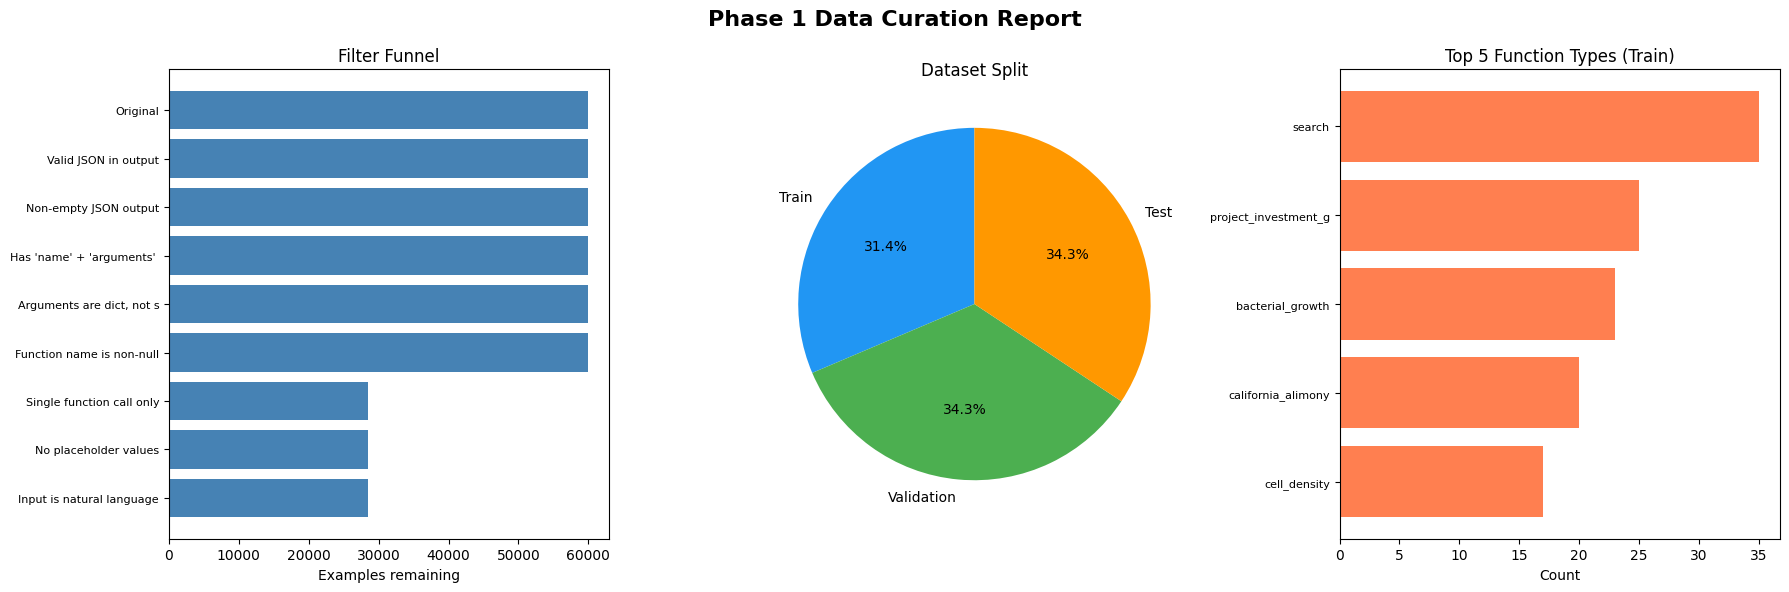

✓ Curation report saved to ./curated_data/curation_report.png


In [28]:
# Cell 19: Visualize your curation pipeline stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Phase 1 Data Curation Report", fontsize=16, fontweight='bold')

# Plot 1: Filter funnel
filter_names = ["Original"] + [f["filter"] for f in filter_stats["after_each_filter"]]
filter_counts = [filter_stats["original"]] + [f["kept"] for f in filter_stats["after_each_filter"]]

# Shorten names for display
short_names = [n.split('(')[0].strip()[:25] for n in filter_names]

axes[0].barh(range(len(short_names)), filter_counts, color='steelblue')
axes[0].set_yticks(range(len(short_names)))
axes[0].set_yticklabels(short_names, fontsize=8)
axes[0].set_xlabel("Examples remaining")
axes[0].set_title("Filter Funnel")
axes[0].invert_yaxis()

# Plot 2: Split distribution
split_labels = ['Train', 'Validation', 'Test']
split_sizes = [len(train_examples), len(val_examples), len(test_examples)]
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[1].pie(split_sizes, labels=split_labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Dataset Split")

# Plot 3: Top 10 function types in train
fn_counts = Counter(ex["function_name"] for ex in train_examples)
top_fns = fn_counts.most_common(5)
fn_names = [f[0][:20] for f in top_fns]
fn_vals = [f[1] for f in top_fns]
axes[2].barh(range(len(fn_names)), fn_vals, color='coral')
axes[2].set_yticks(range(len(fn_names)))
axes[2].set_yticklabels(fn_names, fontsize=8)
axes[2].set_xlabel("Count")
axes[2].set_title("Top 5 Function Types (Train)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{save_path}/curation_report.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Curation report saved to {save_path}/curation_report.png")

In [29]:
# Cell 20: Final summary printout for your notebook

print("=" * 60)
print("PHASE 1 COMPLETE — CURATION SUMMARY")
print("=" * 60)
print(f"  Source dataset:    Salesforce/xlam-function-calling-60k")
print(f"  Original size:     {filter_stats['original']:,}")
print(f"  After curation:    {len(formatted_examples):,}")
print(f"  Retention rate:    {len(formatted_examples)/filter_stats['original']*100:.1f}%")
print()
print(f"  Final splits:")
print(f"    Train:           {len(train_examples):,}")
print(f"    Validation:      {len(val_examples):,}")
print(f"    Test (sealed):   {len(test_examples):,}")
print()
print(f"  Saved to: {save_path}/")
print()
print("FILES CREATED:")
for f in Path(save_path).iterdir():
    print(f"  {f.name}")
print()
print("NEXT STEP: Phase 2 — SFT with QLoRA")
print("  Load your train split and begin training")
print("  DO NOT look at test split until final evaluation")
print("=" * 60)

PHASE 1 COMPLETE — CURATION SUMMARY
  Source dataset:    Salesforce/xlam-function-calling-60k
  Original size:     60,000
  After curation:    25,065
  Retention rate:    41.8%

  Final splits:
    Train:           2,500
    Validation:      2,732
    Test (sealed):   2,732

  Saved to: ./curated_data/

FILES CREATED:
  train
  val.jsonl
  test.jsonl
  validation
  curation_decisions.txt
  dataset_dict.json
  test
  curation_report.png
  train.jsonl

NEXT STEP: Phase 2 — SFT with QLoRA
  Load your train split and begin training
  DO NOT look at test split until final evaluation
